# Style Model Eval and Loss Plots

This notebook plots eval CSVs (ADP/SL/WP/Random/RLCard) and training losses from `logs.csv`.
It keeps frames on the main x-axis and adds a time axis in hours or days when timing data is available.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "semibold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": False,
        "grid.alpha": 0.18,
        "grid.linewidth": 0.8,
    }
)


In [ ]:
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for cand in candidates:
        if (cand / "douzero_checkpoints").exists():
            return cand
    return start

repo_root = find_repo_root(Path.cwd())
logs_dir = repo_root / "douzero_checkpoints" / "style" / "style_model" / "logs"

eval_files = {
    "adp": logs_dir / "adp_eval.csv",
    "sl": logs_dir / "sl_eval.csv",
    "wp": logs_dir / "wp_eval.csv",
    "random": logs_dir / "random_eval.csv",
    "rlcard": logs_dir / "rlcard_eval.csv",
}

logs_csv = logs_dir / "logs.csv"
plots_dir = repo_root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
eval_plot_path = plots_dir / "style_eval_grid.png"
training_plot_path = plots_dir / "style_training_losses.png"

print("Repo root:", repo_root)
print("Logs dir:", logs_dir)
print("Plots dir:", plots_dir)
for name, path in eval_files.items():
    print(f"{name}: {path.exists()} -> {path}")
print("training logs:", logs_csv.exists(), "->", logs_csv)
print("eval plot will be saved to:", eval_plot_path)
print("training plot will be saved to:", training_plot_path)


Repo root: /home/users/yf201/Code/RL-Project/StyleDou
Logs dir: /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs
Plots dir: /home/users/yf201/Code/RL-Project/StyleDou/plots
adp: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/adp_eval.csv
sl: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/sl_eval.csv
wp: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/wp_eval.csv
random: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/random_eval.csv
rlcard: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/rlcard_eval.csv
training logs: True -> /home/users/yf201/Code/RL-Project/StyleDou/douzero_checkpoints/style/style_model/logs/logs.csv
eval plot will be saved to: /home/users/yf201/Code/RL-Project/StyleDou/plots/style_eval_grid.png
trainin

Latest evaluation:, date=2026-04-13 01:36:53 EDT, frames=769,830,400, source=sl, test_type=SL, role=farmer
Saved eval plot to /home/users/yf201/Code/RL-Project/StyleDou/plots/style_eval_grid.png


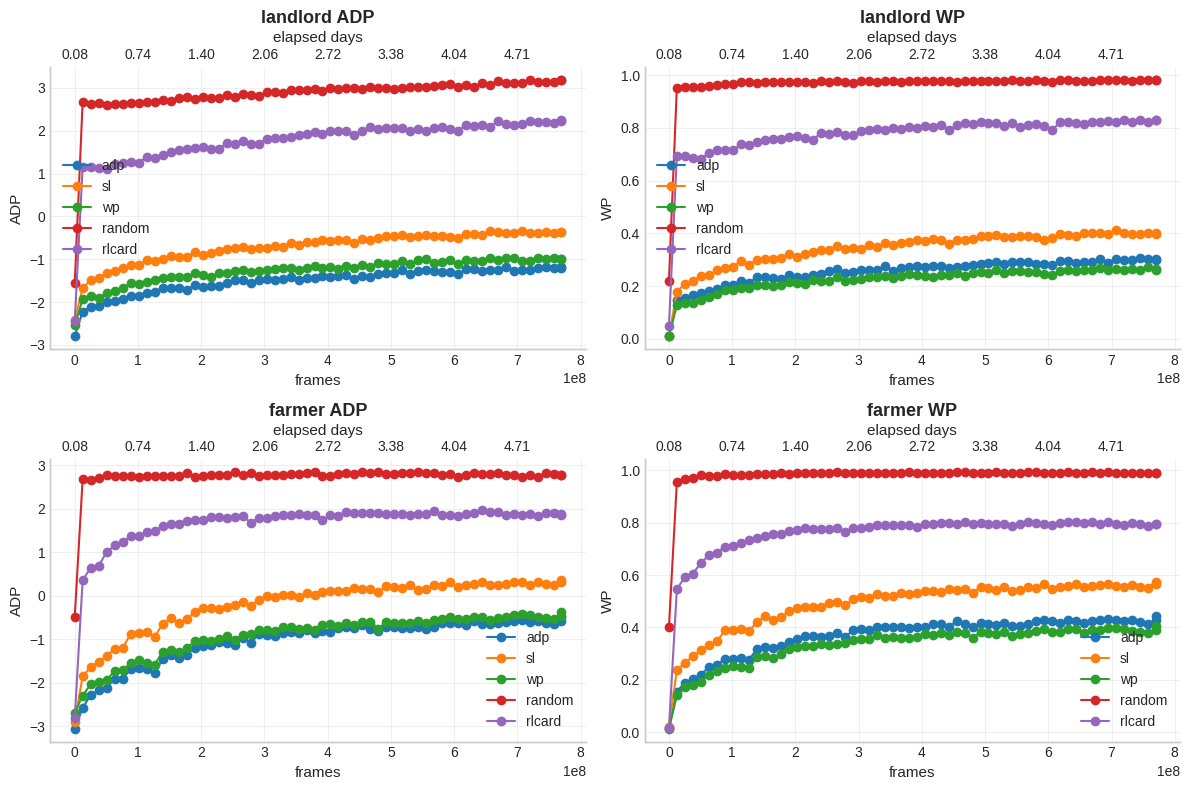

In [ ]:
def load_eval_csv(path):
    if not path.exists():
        return None
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def get_elapsed_seconds(df):
    if "time_seconds" in df.columns:
        series = pd.to_numeric(df["time_seconds"], errors="coerce")
        if series.notna().any():
            return series
    if "_time" in df.columns:
        series = pd.to_numeric(df["_time"], errors="coerce")
        if series.notna().any():
            return series - series.dropna().iloc[0]
    return None

def get_time_axis_config(elapsed_seconds):
    if elapsed_seconds is None:
        return None, None
    valid = pd.to_numeric(elapsed_seconds, errors="coerce").dropna()
    if valid.empty:
        return None, None
    max_hours = valid.max() / 3600
    if max_hours >= 48:
        return 86400, "elapsed days"
    return 3600, "elapsed hours"

def prepare_plot_axis(df):
    elapsed_seconds = get_elapsed_seconds(df)
    if "frames" in df.columns:
        frames = pd.to_numeric(df["frames"], errors="coerce")
        if frames.notna().any():
            return frames, "frames", elapsed_seconds, "frames"
    scale, label = get_time_axis_config(elapsed_seconds)
    if scale is not None:
        return elapsed_seconds / scale, label, elapsed_seconds, "time"
    return pd.Series(range(len(df)), index=df.index, dtype=float), "index", None, "index"

def add_time_axis(ax, x, elapsed_seconds):
    scale, label = get_time_axis_config(elapsed_seconds)
    if scale is None:
        return
    valid = pd.DataFrame(
        {
            "x": pd.to_numeric(x, errors="coerce"),
            "elapsed_seconds": pd.to_numeric(elapsed_seconds, errors="coerce"),
        }
    ).dropna()
    valid = valid.sort_values("x").drop_duplicates(subset="x", keep="last")
    if len(valid) < 2:
        return
    top_ax = ax.twiny()
    top_ax.set_xlim(ax.get_xlim())
    tick_positions = np.asarray(ax.get_xticks(), dtype=float)
    tick_positions = tick_positions[(tick_positions >= valid["x"].min()) & (tick_positions <= valid["x"].max())]
    if len(tick_positions) == 0:
        return
    tick_labels = np.interp(tick_positions, valid["x"], valid["elapsed_seconds"] / scale)
    top_ax.set_xticks(tick_positions)
    top_ax.set_xticklabels([f"{value:.2f}" for value in tick_labels])
    top_ax.set_xlabel(label)
    top_ax.grid(False)

def get_latest_row_info(df, source_name=None):
    if df is None or df.empty:
        return None
    work_df = df.copy()
    sort_col = None
    timestamp = None
    if "timestamp" in work_df.columns:
        work_df["_sort_timestamp"] = pd.to_datetime(work_df["timestamp"], errors="coerce", utc=True)
        if work_df["_sort_timestamp"].notna().any():
            sort_col = "_sort_timestamp"
    if sort_col is None and "_time" in work_df.columns:
        work_df["_sort_time"] = pd.to_numeric(work_df["_time"], errors="coerce")
        if work_df["_sort_time"].notna().any():
            sort_col = "_sort_time"
    if sort_col is None and "time_seconds" in work_df.columns:
        work_df["_sort_elapsed"] = pd.to_numeric(work_df["time_seconds"], errors="coerce")
        if work_df["_sort_elapsed"].notna().any():
            sort_col = "_sort_elapsed"
    if sort_col is None and "frames" in work_df.columns:
        work_df["_sort_frames"] = pd.to_numeric(work_df["frames"], errors="coerce")
        if work_df["_sort_frames"].notna().any():
            sort_col = "_sort_frames"
    if sort_col is None:
        latest = work_df.iloc[-1]
    else:
        latest = work_df.sort_values(sort_col).iloc[-1]
    if "timestamp" in latest and pd.notna(latest.get("timestamp")):
        timestamp = pd.to_datetime(latest["timestamp"], errors="coerce", utc=True)
    elif "_time" in latest and pd.notna(latest.get("_time")):
        timestamp = pd.to_datetime(float(latest["_time"]), unit="s", utc=True)
    frames = pd.to_numeric(latest.get("frames"), errors="coerce") if "frames" in latest.index else np.nan
    info = {
        "source": source_name,
        "timestamp": timestamp,
        "frames": int(frames) if pd.notna(frames) else None,
    }
    for col in ["test_type", "role"]:
        if col in latest.index and pd.notna(latest[col]):
            info[col] = latest[col]
    return info

def format_latest_row_info(label, info):
    if info is None:
        print(f"Latest {label}: unavailable")
        return
    parts = [f"Latest {label}:"]
    if info.get("timestamp") is not None and pd.notna(info["timestamp"]):
        parts.append(f"date={info['timestamp'].tz_convert('America/New_York').strftime('%Y-%m-%d %H:%M:%S %Z')}")
    if info.get("frames") is not None:
        parts.append(f"frames={info['frames']:,}")
    if info.get("source"):
        parts.append(f"source={info['source']}")
    if info.get("test_type"):
        parts.append(f"test_type={info['test_type']}")
    if info.get("role"):
        parts.append(f"role={info['role']}")
    print(", ".join(parts))

def keep_latest_training_segment(df):
    if df is None or df.empty or "frames" not in df.columns:
        return df, {"rollback_count": 0, "duplicate_frame_count": 0}
    work_df = df.copy()
    work_df["_frames_numeric"] = pd.to_numeric(work_df["frames"], errors="coerce")
    valid_frames = work_df["_frames_numeric"].dropna()
    if len(valid_frames) < 2:
        return work_df.drop(columns=["_frames_numeric"]), {"rollback_count": 0, "duplicate_frame_count": 0}
    frame_diffs = work_df["_frames_numeric"].diff()
    rollback_count = int((frame_diffs < 0).sum())
    duplicate_frame_count = int(valid_frames[valid_frames.duplicated(keep=False)].nunique())
    work_df = work_df.dropna(subset=["_frames_numeric"]).copy()
    work_df = work_df.sort_values("_frames_numeric", kind="stable")
    work_df = work_df.drop_duplicates(subset="_frames_numeric", keep="last")
    stats = {
        "rollback_count": rollback_count,
        "duplicate_frame_count": duplicate_frame_count,
    }
    return work_df.drop(columns=["_frames_numeric"]), stats

def plot_eval_grid(eval_data):
    roles = ["landlord", "farmer"]
    metrics = [("adp", "ADP"), ("wp", "WP")]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
    for row_idx, role in enumerate(roles):
        for col_idx, (metric_key, metric_label) in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            has_series = False
            x_label = "index"
            time_axis_x = None
            time_axis_seconds = None
            for test_type, df in eval_data.items():
                if df is None or df.empty or "role" not in df.columns:
                    continue
                role_df = df[df["role"] == role].copy()
                if role_df.empty:
                    continue
                if "frames" in role_df.columns:
                    role_df = role_df.sort_values("frames")
                elif "time_seconds" in role_df.columns:
                    role_df = role_df.sort_values("time_seconds")
                metric_col = f"{metric_key}_{role}"
                if metric_col not in role_df.columns:
                    continue
                x, x_label, elapsed_seconds, x_kind = prepare_plot_axis(role_df)
                metric_series = pd.to_numeric(role_df[metric_col], errors="coerce")
                ax.plot(x, metric_series, marker="o", label=test_type)
                if x_kind == "frames" and time_axis_x is None and elapsed_seconds is not None:
                    time_axis_x = x
                    time_axis_seconds = elapsed_seconds
                has_series = True
            ax.set_title(f"{role} {metric_label}")
            ax.set_xlabel(x_label)
            ax.set_ylabel(metric_label)
            ax.grid(True, alpha=0.3)
            if has_series:
                ax.legend()
                if time_axis_x is not None:
                    add_time_axis(ax, time_axis_x, time_axis_seconds)
            else:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
    fig.tight_layout()
    fig.savefig(eval_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved eval plot to {eval_plot_path}")
    plt.show()

eval_data = {test_type: load_eval_csv(path) for test_type, path in eval_files.items()}
latest_eval_candidates = [get_latest_row_info(df, source_name=test_type) for test_type, df in eval_data.items()]
latest_eval_candidates = [info for info in latest_eval_candidates if info is not None]
latest_eval = None
if latest_eval_candidates:
    latest_eval = max(
        latest_eval_candidates,
        key=lambda info: info["timestamp"] if info.get("timestamp") is not None else pd.Timestamp.min.tz_localize('UTC'),
    )
format_latest_row_info("evaluation", latest_eval)
plot_eval_grid(eval_data)


Training log cleanup: detected 1 frame rollback(s) and 1,837 duplicated frame value(s); keeping the latest row for each frame across concatenated runs.
Latest training loss:, date=2026-04-13 01:55:27 EDT, frames=776,137,600
Training duration: 124.44 hours (5.19 days)
Saved training plot to /home/users/yf201/Code/RL-Project/StyleDou/plots/style_training_losses.png


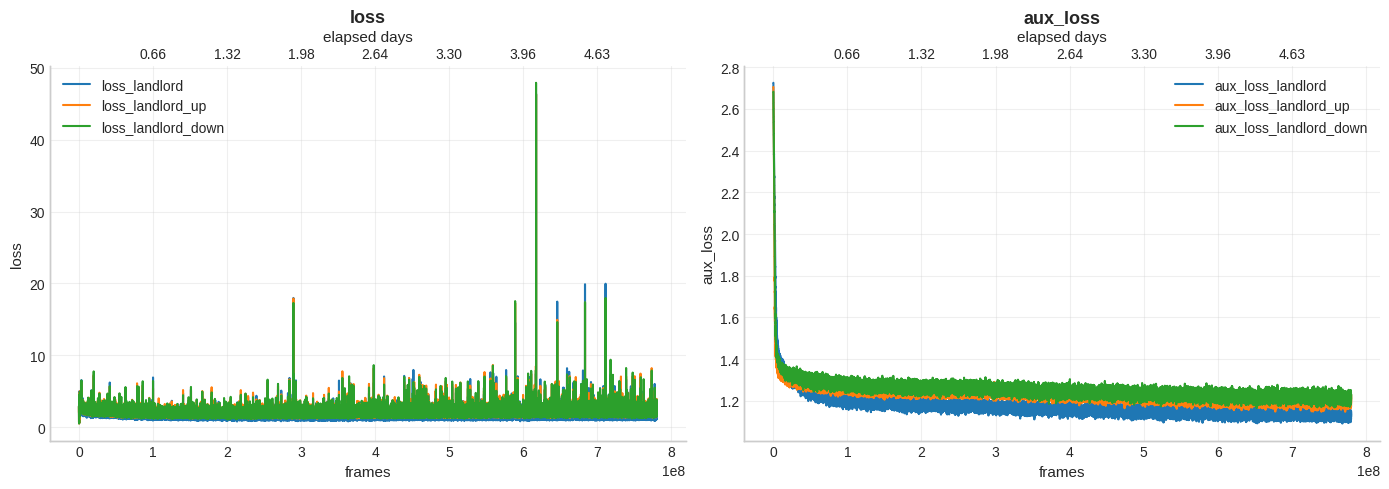

In [ ]:
def load_training_logs(path: Path):
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as handle:
        first_line = handle.readline().strip()
    header = None
    if first_line.startswith("#"):
        header = [c.strip() for c in first_line.lstrip("# ").split(",")]
    if header:
        df = pd.read_csv(path, comment="#", names=header)
    else:
        df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    return df

train_df = load_training_logs(logs_csv)
if train_df is None or train_df.empty:
    print("logs.csv not found or empty")
else:
    train_plot_df = train_df.copy()
    train_plot_df, cleanup_stats = keep_latest_training_segment(train_plot_df)
    rollback_count = cleanup_stats["rollback_count"]
    duplicate_frame_count = cleanup_stats["duplicate_frame_count"]
    if rollback_count or duplicate_frame_count:
        print(
            "Training log cleanup: "
            f"detected {rollback_count} frame rollback(s) and {duplicate_frame_count:,} duplicated frame value(s); "
            "keeping the latest row for each frame across concatenated runs."
        )
    if "frames" in train_plot_df.columns:
        frame_values = pd.to_numeric(train_plot_df["frames"], errors="coerce")
        train_plot_df = train_plot_df[frame_values > 0].copy()
    if train_plot_df.empty:
        print("No training rows remain after removing frame 0.")
    else:
        x, x_label, elapsed_seconds, x_kind = prepare_plot_axis(train_plot_df)
        format_latest_row_info("training loss", get_latest_row_info(train_plot_df))
        valid_elapsed = pd.to_numeric(elapsed_seconds, errors="coerce").dropna() if elapsed_seconds is not None else pd.Series(dtype=float)
        if not valid_elapsed.empty:
            total_hours = valid_elapsed.max() / 3600
            print(f"Training duration: {total_hours:.2f} hours ({total_hours / 24:.2f} days)")

        loss_cols = [col for col in train_plot_df.columns if col.startswith("loss_")]
        aux_cols = [col for col in train_plot_df.columns if col.startswith("aux_loss_")]
        if not loss_cols and not aux_cols:
            loss_cols = [col for col in train_plot_df.columns if "loss" in col]
            aux_cols = []
            for col in loss_cols[:]:
                if col.startswith("aux"):
                    aux_cols.append(col)
                    loss_cols.remove(col)
        if not loss_cols and not aux_cols:
            print("No loss columns found in logs.csv. Columns:")
            print(train_plot_df.columns.tolist())
        else:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
            plot_specs = [
                (axes[0], loss_cols, "loss", "loss", None),
                (axes[1], aux_cols, "aux_loss", "aux_loss", None),
            ]
            for ax, cols, title, ylabel, ylim in plot_specs:
                if cols:
                    for col in cols:
                        series = pd.to_numeric(train_plot_df[col], errors="coerce")
                        valid_mask = series.notna() & (series != 0)
                        ax.plot(x[valid_mask], series[valid_mask], label=col)
                    ax.legend()
                else:
                    ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_title(title)
                ax.set_xlabel(x_label)
                ax.set_ylabel(ylabel)
                if ylim is not None:
                    ax.set_ylim(*ylim)
                ax.grid(True, alpha=0.3)
                if x_kind == "frames" and elapsed_seconds is not None:
                    add_time_axis(ax, x, elapsed_seconds)
            fig.tight_layout()
            fig.savefig(training_plot_path, dpi=200, bbox_inches="tight")
            print(f"Saved training plot to {training_plot_path}")
            plt.show()
